In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

df = pd.read_csv('../../day02/lab06_clean-dataset/results/secom_clean.csv')

sensor_cols = [c for c in df.columns if c.startswith('sensor_')]
df[sensor_cols] = df[sensor_cols].fillna(df[sensor_cols].median())

df['불량여부'] = (df['result'] == '불량').astype(int)

X = df[sensor_cols]
y = df['불량여부']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 로지스틱 회귀는 스케일에 민감해서 표준화를 함께 넣는다 (lab08과 같은 방식)
scaler = StandardScaler()
X_train_표준화 = scaler.fit_transform(X_train)
X_test_표준화 = scaler.transform(X_test)

model = LogisticRegression()  # 불균형 보정 없이 기본 설정 그대로
model.fit(X_train_표준화, y_train)
예측 = model.predict(X_test_표준화)

정확도 = (예측 == y_test).mean()

print('학습용:', X_train.shape[0], '건, 시험용:', X_test.shape[0], '건')
print('정확도:', round(정확도 * 100, 2), '%')

학습용: 1253 건, 시험용: 314 건
정확도: 93.95 %


# 실습 9: 혼동행렬과 분류 결과 리포트
- 상황: 정확도 하나로는 어느 모델이 나은지 답할 수 없다
- 목표: 틀린 것을 두 종류로 나눠 보고, 오늘 결과를 리포트 한 장으로 마감한다

## Step 0. 앞 실습까지 재현하기

## Step 1. 오늘 쓸 말 정리하기

### 용어 풀이 - 결과를 네 칸으로 나눠 볼 때 쓰는 말

| 말 | 뜻 |
|---|---|
| 혼동행렬 | 맞힌 것과 틀린 것을 네 칸으로 나눠 놓은 표 |
| 놓친 불량 | 불량인데 양품이라 한 것. 걸러지지 않고 고객에게 간다 |
| 헛경보 | 양품인데 불량이라 한 것. 멀쩡한 것을 세워 다시 본다 |
| 재현율 (recall) | 실제 불량 중 몇 %를 잡았나 |
| 정밀도 (precision) | 불량이라 한 것 중 진짜가 몇 %였나 |
| F1 | 재현율과 정밀도를 함께 보는 값. 한쪽만 좋으면 오르지 않는다 |

## Step 2. 네 칸으로 쪼개기

In [2]:
# confusion_matrix - 실제 답과 예측을 맞대어 네 칸으로 세어준다
from sklearn.metrics import confusion_matrix

행렬 = confusion_matrix(y_test, 예측)
print(행렬)

# ravel() - 네 칸을 한 줄로 펴서 하나씩 이름을 붙여 받는다
# 순서가 정해져 있다: 왼쪽위, 오른쪽위, 왼쪽아래, 오른쪽아래
맞힌양품, 헛경보, 놓친불량, 잡은불량 = 행렬.ravel()

print("양품인데 양품이라 함 :", 맞힌양품)
print("양품인데 불량이라 함 :", 헛경보,   " <- 헛경보")
print("불량인데 양품이라 함 :", 놓친불량, " <- 놓친 불량")
print("불량인데 불량이라 함 :", 잡은불량)

[[293   0]
 [ 19   2]]
양품인데 양품이라 함 : 293
양품인데 불량이라 함 : 0  <- 헛경보
불량인데 양품이라 함 : 19  <- 놓친 불량
불량인데 불량이라 함 : 2


## Step 3. 네 칸이 현장에서 무슨 상황인가

| 칸 | 내 숫자 | 현장에서는 |
|---|---|---|
| 양품인데 양품 | [293] | 아무 일 없음 |
| 양품인데 불량 (헛경보) | [0] | 멀쩡한 걸 세우고 다시 본다. 사람 손이 든다 |
| 불량인데 양품 (놓친 불량) | [19] | 걸러지지 않고 고객에게 간다 |
| 불량인데 불량 | [2] | 원하던 것. 미리 잡았다 |

## Step 4. 두 지표를 손으로 계산하기

In [3]:
# 재현율 - 실제 불량 중 몇 %를 잡았나
# 분모는 "실제 불량 전체" = 잡은 것 + 놓친 것
재현율 = 잡은불량 / (잡은불량 + 놓친불량)

# 정밀도 - 불량이라 한 것 중 진짜가 몇 %였나
# 분모는 "불량이라고 한 것 전체" = 진짜 + 헛경보
정밀도 = 잡은불량 / (잡은불량 + 헛경보)

print("재현율:", round(재현율, 3), " <- 실제 불량", 잡은불량 + 놓친불량, "건 중", 잡은불량, "건")
print("정밀도:", round(정밀도, 3), " <- 불량이라 한", 잡은불량 + 헛경보, "건 중", 잡은불량, "건")

재현율: 0.095  <- 실제 불량 21 건 중 2 건
정밀도: 1.0  <- 불량이라 한 2 건 중 2 건


### 문법 노트 - 네 칸에서 지표 뽑기

| 쓴 것 | 하는 일 | 왜 여기 쓰나 |
|---|---|---|
| confusion_matrix(실제, 예측) | 맞고 틀림을 네 칸으로 세어준다 | 정확도 하나로는 안 보이는 걸 본다 |
| .ravel() | 네 칸을 한 줄로 펴준다 | 칸마다 이름을 붙여 받으려고 |
| classification_report | 지표를 한 번에 계산해 표로 보여준다 | 손으로 구한 값과 맞춰보려고 |

**분자는 둘 다 같고 분모가 다르다.**<br>
재현율 = 잡은불량 / (잡은불량 + 놓친불량)   분모가 "실제 불량 전체"<br>
정밀도 = 잡은불량 / (잡은불량 + 헛경보)     분모가 "불량이라 한 것 전체"<br>
헷갈리면 분모부터 정하면 된다.

## Step 5. 라이브러리 출력과 대조하기

In [4]:
from sklearn.metrics import classification_report

# target_names - 0과 1 대신 사람이 읽을 이름을 붙인다
# digits=3 - 소수점 셋째 자리까지
print(classification_report(y_test, 예측,
                            target_names=["양품", "불량"], digits=3))

              precision    recall  f1-score   support

          양품      0.939     1.000     0.969       293
          불량      1.000     0.095     0.174        21

    accuracy                          0.939       314
   macro avg      0.970     0.548     0.571       314
weighted avg      0.943     0.939     0.915       314



## Step 6. 기준 모델의 재현율은 얼마인가

In [5]:
import numpy as np
import warnings
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score

# 기준 모델을 다시 만든다 - 시험용 전부 양품(0)으로 답
기준예측 = np.zeros(len(y_test), dtype=int)

# 기준 모델은 불량이라 한 것이 0건이라, 정밀도의 분모(불량이라 한 것 전체)가 0이 된다
# zero_division 없이 그대로 계산하면 뜨는 경고를 먼저 확인해본다
with warnings.catch_warnings(record=True) as 경고들:
    warnings.simplefilter('always')
    precision_score(y_test, 기준예측)
    print('경고 메시지:', str(경고들[0].message) if 경고들 else '(경고 없음)')


def 평가(이름, 예측값):
    return {
        '모델': 이름,
        '정확도(%)': round(accuracy_score(y_test, 예측값) * 100, 1),
        '재현율(%)': round(recall_score(y_test, 예측값, zero_division=0) * 100, 1),
        # 정밀도 분모가 0이 되는 경우(불량 예측이 0건) zero_division=0으로 0 처리
        '정밀도(%)': round(precision_score(y_test, 예측값, zero_division=0) * 100, 1),
        'F1(%)': round(f1_score(y_test, 예측값, zero_division=0) * 100, 1),
        '놓친 불량 건수': int(((예측값 == 0) & (y_test == 1)).sum()),
        '헛경보 건수': int(((예측값 == 1) & (y_test == 0)).sum()),
    }


비교표 = pd.DataFrame([
    평가('기준 모델 (전부 양품)', 기준예측),
    평가('로지스틱 회귀', 예측),
]).set_index('모델')

비교표

경고 메시지: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.


,정확도(%),재현율(%),정밀도(%),F1(%),놓친 불량 건수,헛경보 건수
모델,,,,,,
기준 모델 (전부 양품),93.3,0.0,0.0,0.0,21,0
로지스틱 회귀,93.9,9.5,100.0,17.4,19,0


## Step 7. 문턱을 낮춰 더 잡아보기

In [6]:
# predict_proba - 모델을 다시 학습시키지 않고, 이미 학습된 model에 시험용을 넣어 "불량일 확률"만 뽑는다
# [:, 1] - 두 번째 열이 클래스 1(불량)일 확률
불량확률 = model.predict_proba(X_test_표준화)[:, 1]

print('불량확률 예시 (앞 5개):', np.round(불량확률[:5], 3))
print('불량확률 최댓값:', round(불량확률.max(), 3), ' / 최솟값:', round(불량확률.min(), 3))

불량확률 예시 (앞 5개): [0.02  0.038 0.102 0.014 0.093]
불량확률 최댓값: 0.964  / 최솟값: 0.0


In [7]:
# 문턱값을 바꿔가며 비교 - 예측을 새로 만들되, 기존 "예측"(문턱 0.5 고정, .predict()) 변수는 건드리지 않는다
문턱값들 = [0.5, 0.3, 0.2, 0.1]

# 문턱별 예측을 이름별로 따로 보관 (기존 예측과 구분되는 새 이름)
예측_문턱별 = {문턱: (불량확률 >= 문턱).astype(int) for 문턱 in 문턱값들}


def 문턱평가(문턱, 예측값):
    잡은불량 = int(((예측값 == 1) & (y_test == 1)).sum())
    놓친불량 = int(((예측값 == 0) & (y_test == 1)).sum())
    헛경보 = int(((예측값 == 1) & (y_test == 0)).sum())
    return {
        '문턱': 문턱,
        '잡은 불량 건수': 잡은불량,
        '놓친 불량 건수': 놓친불량,
        '헛경보 건수': 헛경보,
        '재현율': round(recall_score(y_test, 예측값, zero_division=0), 3),
        '정밀도': round(precision_score(y_test, 예측값, zero_division=0), 3),
    }


문턱비교표 = pd.DataFrame([
    문턱평가(문턱, 예측_문턱별[문턱]) for 문턱 in 문턱값들
]).set_index('문턱')

문턱비교표

,잡은 불량 건수,놓친 불량 건수,헛경보 건수,재현율,정밀도
문턱,,,,,
0.5,2,19,0,0.095,1.000
0.3,3,18,6,0.143,0.333
0.2,5,16,13,0.238,0.278
0.1,9,12,42,0.429,0.176


### 문턱을 낮추면

| 문턱 | 잡은 불량 | 놓친 불량 | 헛경보 | 재현율 | 정밀도 |
|---|---|---|---|---|---|
| 0.5 | [2] | [19] | [0] | [0.095] | [1.000] |
| 0.3 | [3] | [18] | [6] | [0.143] | [0.333] |
| 0.2 | [5] | [16] | [13] | [0.238] | [0.278] |
| 0.1 | [9] | [12] | [42] | [0.429] | [0.176] |

## Step 8. 분류 결과 리포트 마감하기

In [8]:
import os

# 이미 메모리에 있는 df(정제본)·X_train·X_test에서 그대로 읽어온다 - 다시 계산하지 않음
정제본_행수, 정제본_열수 = df.shape
불량비율 = round(df['불량여부'].mean() * 100, 2)
학습용_건수 = X_train.shape[0]
시험용_건수 = X_test.shape[0]

os.makedirs('results', exist_ok=True)

print('정제본 행 수:', 정제본_행수, '/ 열 수:', 정제본_열수)
print('불량 비율(%):', 불량비율)
print('학습용:', 학습용_건수, '건 / 시험용:', 시험용_건수, '건')

정제본 행 수: 1567 / 열 수: 52
불량 비율(%): 6.64
학습용: 1253 건 / 시험용: 314 건


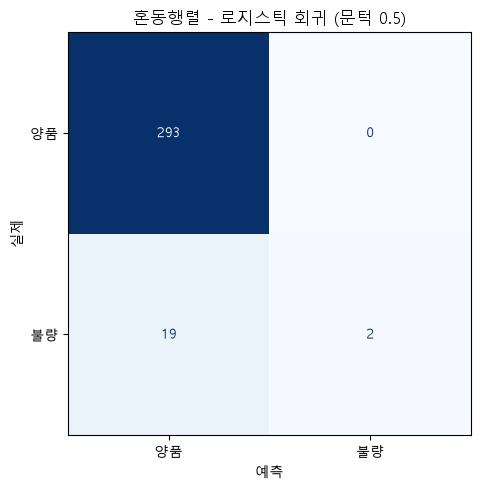

저장 완료: C:\Users\13sx0\Desktop\SECOM-PROJECT\day03\lab09_confusion-matrix\results\confusion_matrix.png


In [9]:
# 혼동행렬 그림 - 이미 계산된 행렬(confusion_matrix(y_test, 예측))을 그대로 그림으로 옮긴다
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

fig, ax = plt.subplots(figsize=(5, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=행렬, display_labels=['양품', '불량'])
disp.plot(ax=ax, cmap='Blues', colorbar=False, values_format='d')
ax.set_xlabel('예측')
ax.set_ylabel('실제')
ax.set_title('혼동행렬 - 로지스틱 회귀 (문턱 0.5)')
plt.tight_layout()
plt.savefig('results/confusion_matrix.png', dpi=150)
plt.show()

print('저장 완료:', os.path.abspath('results/confusion_matrix.png'))

In [10]:
# report.md 작성 - 전부 이 노트북에서 이미 계산된 변수(df, X_train, X_test, model, scaler, 비교표, 행렬, 문턱비교표)를 그대로 옮긴다

줄 = []
줄.append('# 분류 결과 리포트')
줄.append('')

줄.append('## 1. 데이터')
줄.append(f'- 정제본 행 수: {정제본_행수}')
줄.append(f'- 정제본 열 수: {정제본_열수}')
줄.append(f'- 불량 비율: {불량비율}%')
줄.append(f'- 학습용 건수: {학습용_건수}')
줄.append(f'- 시험용 건수: {시험용_건수}')
줄.append('')

줄.append('## 2. 모델')
줄.append(f'- 모델: {type(model).__name__}')
줄.append(f'- 함께 적용한 처리: {type(scaler).__name__} (표준화)')
줄.append('')

줄.append('## 3. 결과 표')
줄.append('| 모델 | 정확도(%) | 재현율(%) | 정밀도(%) | F1(%) | 놓친 불량 건수 | 헛경보 건수 |')
줄.append('|---|---|---|---|---|---|---|')
for 이름, 행 in 비교표.iterrows():
    줄.append(f"| {이름} | {행['정확도(%)']} | {행['재현율(%)']} | {행['정밀도(%)']} | {행['F1(%)']} | {int(행['놓친 불량 건수'])} | {int(행['헛경보 건수'])} |")
줄.append('')

줄.append('## 4. 혼동행렬 (로지스틱 회귀, 문턱 0.5)')
줄.append('| | 예측: 양품 | 예측: 불량 |')
줄.append('|---|---|---|')
줄.append(f'| 실제: 양품 | {맞힌양품} | {헛경보} |')
줄.append(f'| 실제: 불량 | {놓친불량} | {잡은불량} |')
줄.append('')

줄.append('## 5. 문턱별 비교표')
줄.append('| 문턱 | 잡은 불량 건수 | 놓친 불량 건수 | 헛경보 건수 | 재현율 | 정밀도 |')
줄.append('|---|---|---|---|---|---|')
for 문턱, 행 in 문턱비교표.iterrows():
    줄.append(f"| {문턱} | {int(행['잡은 불량 건수'])} | {int(행['놓친 불량 건수'])} | {int(행['헛경보 건수'])} | {행['재현율']} | {행['정밀도']} |")
줄.append('')

줄.append('## 6. 그림 파일')
줄.append('- results/confusion_matrix.png')
줄.append('')

리포트_내용 = '\n'.join(줄)

with open('results/report.md', 'w', encoding='utf-8') as f:
    f.write(리포트_내용)

print(리포트_내용)

# 분류 결과 리포트

## 1. 데이터
- 정제본 행 수: 1567
- 정제본 열 수: 52
- 불량 비율: 6.64%
- 학습용 건수: 1253
- 시험용 건수: 314

## 2. 모델
- 모델: LogisticRegression
- 함께 적용한 처리: StandardScaler (표준화)

## 3. 결과 표
| 모델 | 정확도(%) | 재현율(%) | 정밀도(%) | F1(%) | 놓친 불량 건수 | 헛경보 건수 |
|---|---|---|---|---|---|---|
| 기준 모델 (전부 양품) | 93.3 | 0.0 | 0.0 | 0.0 | 21 | 0 |
| 로지스틱 회귀 | 93.9 | 9.5 | 100.0 | 17.4 | 19 | 0 |

## 4. 혼동행렬 (로지스틱 회귀, 문턱 0.5)
| | 예측: 양품 | 예측: 불량 |
|---|---|---|
| 실제: 양품 | 293 | 0 |
| 실제: 불량 | 19 | 2 |

## 5. 문턱별 비교표
| 문턱 | 잡은 불량 건수 | 놓친 불량 건수 | 헛경보 건수 | 재현율 | 정밀도 |
|---|---|---|---|---|---|
| 0.5 | 2 | 19 | 0 | 0.095 | 1.0 |
| 0.3 | 3 | 18 | 6 | 0.143 | 0.333 |
| 0.2 | 5 | 16 | 13 | 0.238 | 0.278 |
| 0.1 | 9 | 12 | 42 | 0.429 | 0.176 |

## 6. 그림 파일
- results/confusion_matrix.png



In [11]:
# report.md 안 숫자가 노트북 실행값(변수)과 같은지 대조
검증항목 = {
    '정제본 행 수': str(정제본_행수),
    '정제본 열 수': str(정제본_열수),
    '불량 비율': str(불량비율),
    '학습용 건수': str(학습용_건수),
    '시험용 건수': str(시험용_건수),
    '모델명': type(model).__name__,
    '표준화 처리': type(scaler).__name__,
    '혼동행렬 맞힌양품': str(맞힌양품),
    '혼동행렬 헛경보': str(헛경보),
    '혼동행렬 놓친불량': str(놓친불량),
    '혼동행렬 잡은불량': str(잡은불량),
}
for 이름, 행 in 비교표.iterrows():
    for 열 in ['정확도(%)', '재현율(%)', '정밀도(%)', 'F1(%)']:
        검증항목[f'{이름} {열}'] = str(행[열])
for 문턱, 행 in 문턱비교표.iterrows():
    for 열 in ['잡은 불량 건수', '놓친 불량 건수', '헛경보 건수', '재현율', '정밀도']:
        검증항목[f'문턱 {문턱} {열}'] = str(행[열]) if 열 in ('재현율', '정밀도') else str(int(행[열]))

with open('results/report.md', 'r', encoding='utf-8') as f:
    저장된내용 = f.read()

불일치 = [f'{항목} (기대값: {값})' for 항목, 값 in 검증항목.items() if 값 not in 저장된내용]

print('대조한 항목 수:', len(검증항목))
if 불일치:
    print('불일치 항목:')
    for 항목 in 불일치:
        print(' -', 항목)
else:
    print('불일치 없음 - report.md의 모든 숫자가 노트북 실행값과 일치함')

대조한 항목 수: 39
불일치 없음 - report.md의 모든 숫자가 노트북 실행값과 일치함


In [12]:
# 의사결정나무도 같은 방식으로 문턱을 바꿔보면 어떨까 - 트리는 스케일에 안 민감해서 원래 X_train/X_test 그대로 사용 (lab08과 같은 방식)
from sklearn.tree import DecisionTreeClassifier

트리모델 = DecisionTreeClassifier(random_state=42)
트리모델.fit(X_train, y_train)
트리_불량확률 = 트리모델.predict_proba(X_test)[:, 1]

트리확률종류 = sorted(np.unique(트리_불량확률))
print('의사결정나무의 불량 가능성 값 종류:', 트리확률종류[:2], '...' if len(트리확률종류) > 2 else '')
print('실제 값 종류 개수:', len(트리확률종류))

의사결정나무의 불량 가능성 값 종류: [np.float64(0.0), np.float64(1.0)] 
실제 값 종류 개수: 2


In [13]:
# 의사결정나무도 문턱별로 예측을 만들어본다 (모델은 다시 학습 안 시킴, 문턱평가 함수도 앞에서 만든 것 그대로 재사용)
예측_트리_문턱별 = {문턱: (트리_불량확률 >= 문턱).astype(int) for 문턱 in 문턱값들}

트리문턱비교표 = pd.DataFrame([
    문턱평가(문턱, 예측_트리_문턱별[문턱]) for 문턱 in 문턱값들
]).set_index('문턱')

print('[의사결정나무]')
트리문턱비교표

[의사결정나무]


,잡은 불량 건수,놓친 불량 건수,헛경보 건수,재현율,정밀도
문턱,,,,,
0.5,5,16,26,0.238,0.161
0.3,5,16,26,0.238,0.161
0.2,5,16,26,0.238,0.161
0.1,5,16,26,0.238,0.161


In [14]:
# 두 모델을 나란히 놓고 본다
나란히비교표 = pd.concat(
    {'로지스틱 회귀': 문턱비교표, '의사결정나무': 트리문턱비교표},
    axis=1,
)

print('[두 모델 나란히] 시험용', len(y_test), '건 / 실제 불량', int(y_test.sum()), '건')
print('앞에서 만든 것 그대로 - 문턱표 0.5의 잡은 불량:', int(문턱비교표.loc[0.5, '잡은 불량 건수']), '건')
나란히비교표

[두 모델 나란히] 시험용 314 건 / 실제 불량 21 건
앞에서 만든 것 그대로 - 문턱표 0.5의 잡은 불량: 2 건


로지스틱 회귀                                 의사결정나무                         \
    잡은 불량 건수 놓친 불량 건수 헛경보 건수    재현율    정밀도 잡은 불량 건수 놓친 불량 건수 헛경보 건수    재현율   
문턱                                                                           
0.5        2       19      0  0.095  1.000        5       16     26  0.238   
0.3        3       18      6  0.143  0.333        5       16     26  0.238   
0.2        5       16     13  0.238  0.278        5       16     26  0.238   
0.1        9       12     42  0.429  0.176        5       16     26  0.238   

            
       정밀도  
문턱          
0.5  0.161  
0.3  0.161  
0.2  0.161  
0.1  0.161

### 요약 - 의사결정나무는 왜 문턱을 바꿔도 그대로일까

| 확인한 것 | 값 |
|---|---|
| 의사결정나무가 내놓는 "불량 확률" 값 종류 | [0.0] 또는 [1.0] 두 가지뿐 (실제 값 종류 개수: [2]) |
| 문턱 0.5 / 0.3 / 0.2 / 0.1 결과 | 네 문턱 모두 동일: 잡은 불량 [5]건, 놓친 불량 [16]건, 헛경보 [26]건, 재현율 [0.238], 정밀도 [0.161] |

**쉽게 풀면:** 의사결정나무는 데이터를 "예/아니오" 질문으로 계속 나눠서 마지막에 도착한 한 칸(잎)에 속한 것들을 전부 같은 답으로 취급한다. 그 칸 안이 전부 불량이면 확률 100%(1.0), 전부 양품이면 0%(0.0)라고만 답하고, 그 사이 값은 만들지 않는다. 그래서 문턱을 0.5로 잡든 0.1로 잡든 "1.0인 것만 불량"이라는 판정 결과가 똑같이 나온다.

반대로 로지스틱 회귀는 0.02, 0.038처럼 답이 연속된 숫자라서, 문턱을 낮출수록(0.5→0.1) 더 많은 건이 "불량"으로 넘어가 결과표가 계속 바뀐다(잡은 불량 [2]→[9]건).

| 문턱 | 로지스틱 회귀 잡은 불량 | 로지스틱 회귀 헛경보 | 의사결정나무 잡은 불량 | 의사결정나무 헛경보 |
|---|---|---|---|---|
| 0.5 | [2] | [0] | [5] | [26] |
| 0.3 | [3] | [6] | [5] | [26] |
| 0.2 | [5] | [13] | [5] | [26] |
| 0.1 | [9] | [42] | [5] | [26] |

---
## Q8. 혼동행렬 네 칸 채우기

In [15]:
# Step 2에서 이미 계산해 둔 혼동행렬(행렬)과 네 칸 변수를 그대로 가져와 다시 확인한다
print('[혼동행렬]')
print(행렬)
print()
print('양품인데 양품이라 함 :', 맞힌양품, '건')
print('양품인데 불량이라 함 :', 헛경보, '건 (헛경보)')
print('불량인데 양품이라 함 :', 놓친불량, '건 (놓친 불량)')
print('불량인데 불량이라 함 :', 잡은불량, '건')

[혼동행렬]
[[293   0]
 [ 19   2]]

양품인데 양품이라 함 : 293 건
양품인데 불량이라 함 : 0 건 (헛경보)
불량인데 양품이라 함 : 19 건 (놓친 불량)
불량인데 불량이라 함 : 2 건


[Q8 결과]<br>
양품인데 양품이라 함 : [293]건<br>
양품인데 불량이라 함(헛경보) : [0]건<br>
불량인데 양품이라 함(놓친 불량) : [19]건<br>
불량인데 불량이라 함 : [2]건